# 🏦 Loan Approval Prediction
### End-to-End ML Pipeline: Preprocessing → Training → Evaluation

**Dataset:** `loan_approval_dataset.csv`  
**Target:** `loan_status` (Approved / Rejected)  
**Methods:** Logistic Regression, Decision Tree, Random Forest, Gradient Boosting, AdaBoost, SVM, KNN, Naive Bayes


## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve, f1_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

print("All libraries imported successfully ✅")


All libraries imported successfully ✅


## 2. Load Data

In [2]:
df = pd.read_csv('loan_approval_dataset.csv')

# Strip leading/trailing whitespace from column names
df.columns = df.columns.str.strip()

print(f"Shape: {df.shape}")
df.head()


Shape: (4269, 13)


,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [3]:
print("Data Types:")
print(df.dtypes)
print()
print("Missing Values:")
print(df.isnull().sum())


Data Types:
loan_id                      int64
no_of_dependents             int64
education                   object
self_employed               object
income_annum                 int64
loan_amount                  int64
loan_term                    int64
cibil_score                  int64
residential_assets_value     int64
commercial_assets_value      int64
luxury_assets_value          int64
bank_asset_value             int64
loan_status                 object
dtype: object

Missing Values:
loan_id                     0
no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_status                 0
dtype: int64


## 3. Exploratory Data Analysis

In [4]:
print("Target Distribution:")
print(df['loan_status'].value_counts())
print()
print(f"Approval Rate: {(df['loan_status']=='Approved').mean()*100:.1f}%")


Target Distribution:
loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64

Approval Rate: 0.0%


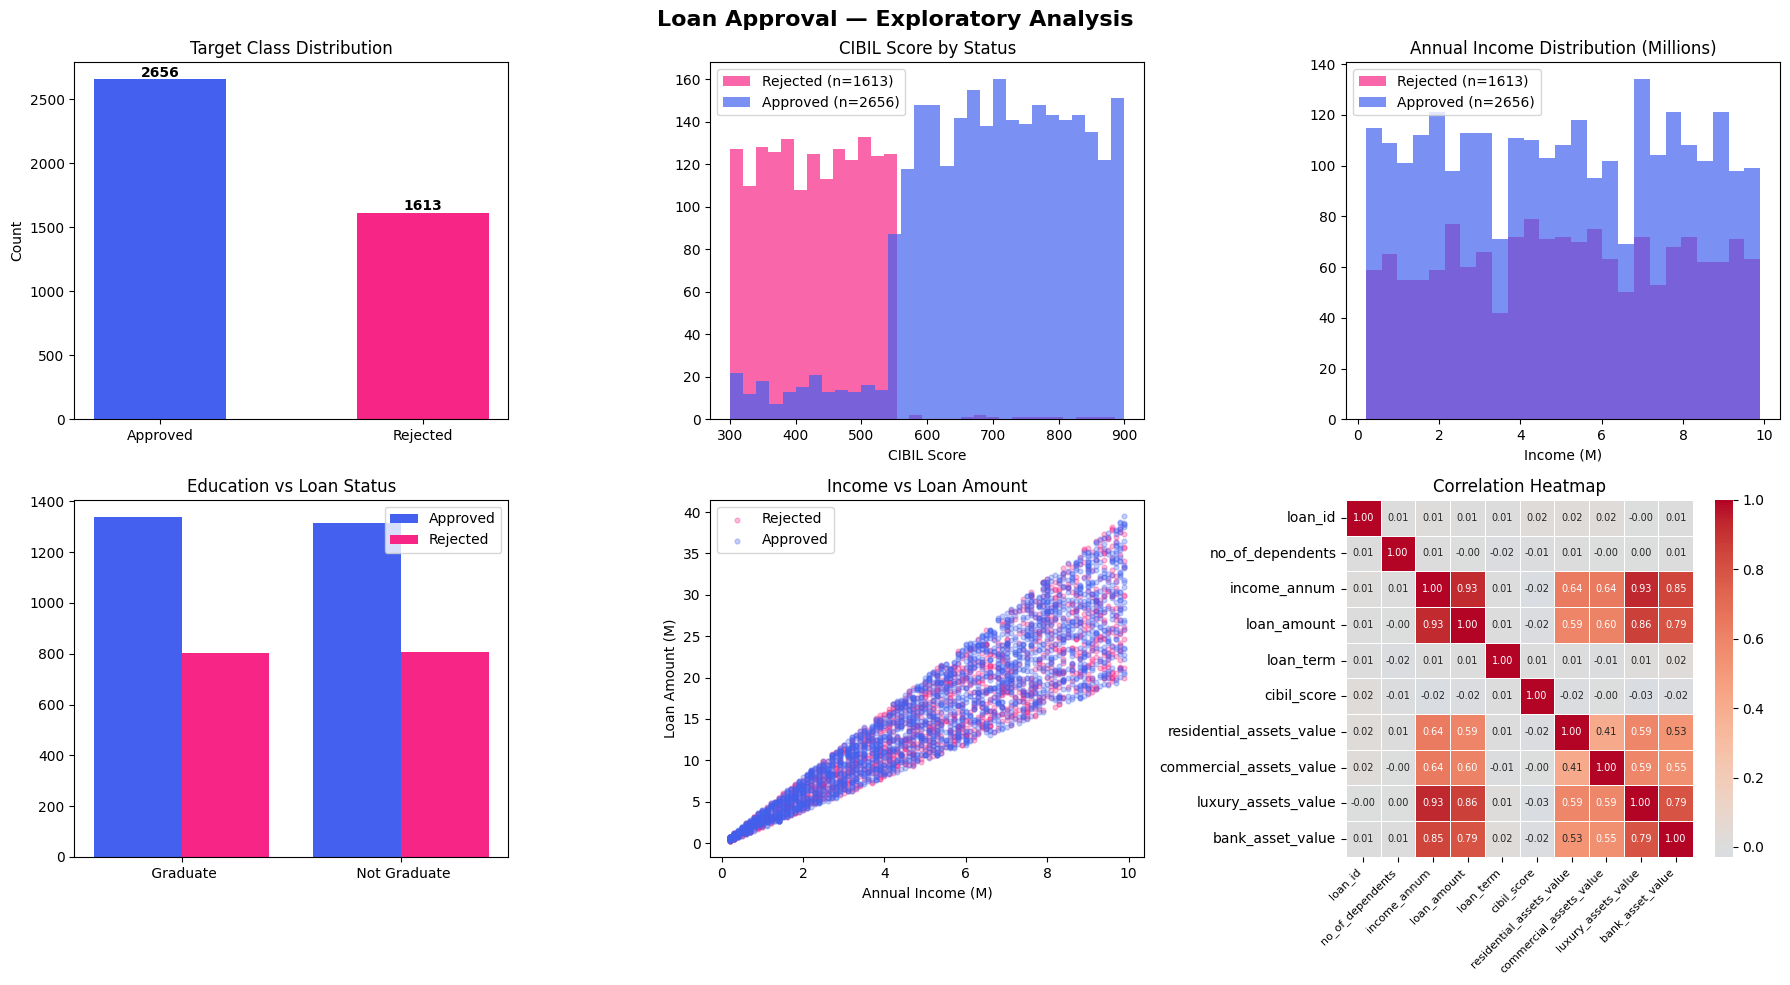

In [5]:
# Always use a fresh raw copy so this cell works regardless of run order
df_eda = pd.read_csv('loan_approval_dataset.csv')
df_eda.columns = df_eda.columns.str.strip()
df_eda['loan_status'] = df_eda['loan_status'].str.strip()  # guard against whitespace

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Loan Approval — Exploratory Analysis', fontsize=16, fontweight='bold')

# --- Plot 1: Target distribution ---
counts = df_eda['loan_status'].value_counts()
bars = axes[0,0].bar(counts.index, counts.values, color=['#4361EE','#F72585'], width=0.5)
axes[0,0].set_title('Target Class Distribution')
axes[0,0].set_ylabel('Count')
for bar, val in zip(bars, counts.values):
    axes[0,0].text(bar.get_x() + bar.get_width()/2, val + 20,
                   str(val), ha='center', fontweight='bold')

# --- Plot 2: CIBIL score distribution ---
for label, color in zip(['Rejected', 'Approved'], ['#F72585', '#4361EE']):
    subset = df_eda[df_eda['loan_status'] == label]['cibil_score']
    axes[0,1].hist(subset, bins=30, alpha=0.7, color=color, label=f"{label} (n={len(subset)})")
axes[0,1].set_title('CIBIL Score by Status')
axes[0,1].set_xlabel('CIBIL Score')
axes[0,1].legend()

# --- Plot 3: Income distribution ---
for label, color in zip(['Rejected', 'Approved'], ['#F72585', '#4361EE']):
    subset = df_eda[df_eda['loan_status'] == label]['income_annum'] / 1e6
    axes[0,2].hist(subset, bins=25, alpha=0.7, color=color, label=f"{label} (n={len(subset)})")
axes[0,2].set_title('Annual Income Distribution (Millions)')
axes[0,2].set_xlabel('Income (M)')
axes[0,2].legend()

# --- Plot 4: Education vs loan status ---
edu_ct = df_eda.groupby(['education', 'loan_status']).size().unstack(fill_value=0)
x = np.arange(len(edu_ct))
axes[1,0].bar(x - 0.2, edu_ct.get('Approved', 0), 0.4, color='#4361EE', label='Approved')
axes[1,0].bar(x + 0.2, edu_ct.get('Rejected', 0), 0.4, color='#F72585', label='Rejected')
axes[1,0].set_xticks(x)
axes[1,0].set_xticklabels(edu_ct.index)
axes[1,0].set_title('Education vs Loan Status')
axes[1,0].legend()

# --- Plot 5: Income vs Loan Amount scatter ---
approved_df = df_eda[df_eda['loan_status'] == 'Approved']
rejected_df = df_eda[df_eda['loan_status'] == 'Rejected']
axes[1,1].scatter(rejected_df['income_annum']/1e6, rejected_df['loan_amount']/1e6,
                  alpha=0.3, s=12, color='#F72585', label='Rejected')
axes[1,1].scatter(approved_df['income_annum']/1e6, approved_df['loan_amount']/1e6,
                  alpha=0.3, s=12, color='#4361EE', label='Approved')
axes[1,1].set_xlabel('Annual Income (M)')
axes[1,1].set_ylabel('Loan Amount (M)')
axes[1,1].set_title('Income vs Loan Amount')
axes[1,1].legend()

# --- Plot 6: Correlation heatmap (numeric columns only) ---
num_cols = df_eda.select_dtypes(include=[np.number]).columns.tolist()
corr = df_eda[num_cols].corr()
sns.heatmap(corr, ax=axes[1,2], cmap='coolwarm', center=0,
            annot=True, fmt='.2f', annot_kws={'size': 7}, linewidths=0.5)
axes[1,2].set_title('Correlation Heatmap')
plt.setp(axes[1,2].get_xticklabels(), rotation=45, ha='right', fontsize=8)

plt.tight_layout()
plt.show()


## 4. ⚙️ Preprocessing

Steps:
1. Drop `loan_id` (non-informative identifier)
2. Label-encode categorical columns (`education`, `self_employed`)
3. Encode target: `Approved = 1`, `Rejected = 0`
4. Split features / target
5. Apply `StandardScaler`
6. Stratified 80/20 train-test split


In [6]:
# Always reload from CSV so this cell is safe to re-run in any order
df_proc = pd.read_csv('loan_approval_dataset.csv')
df_proc.columns = df_proc.columns.str.strip()

# --- Step 1: Drop ID column ---
df_proc = df_proc.drop(columns=['loan_id'])

# --- Step 2: Encode categorical features ---
# education:     Graduate -> 0,  Not Graduate -> 1
# self_employed: No       -> 0,  Yes          -> 1
df_proc['education']     = (df_proc['education']     == 'Not Graduate').astype(int)
df_proc['self_employed'] = (df_proc['self_employed'] == 'Yes').astype(int)

# --- Step 3: Encode target (explicit string comparison — never fails) ---
# Approved = 1, Rejected = 0
df_proc['loan_status'] = (df_proc['loan_status'].str.strip() == 'Approved').astype(int)

# Sanity check
print('✅ Encoding complete')
print(f"   education unique values      : {sorted(df_proc['education'].unique())}")
print(f"   self_employed unique values  : {sorted(df_proc['self_employed'].unique())}")
print(f"   loan_status unique values    : {sorted(df_proc['loan_status'].unique())}")
print(f"   Approved (1): {df_proc['loan_status'].sum()}  |  Rejected (0): {(df_proc['loan_status']==0).sum()}")
df_proc.head()


✅ Encoding complete
   education unique values      : [np.int64(0)]
   self_employed unique values  : [np.int64(0)]
   loan_status unique values    : [np.int64(0), np.int64(1)]
   Approved (1): 2656  |  Rejected (0): 1613


,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,0,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,1
1,0,0,0,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0
2,3,0,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0
3,3,0,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0
4,5,0,0,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0


In [7]:
# --- Step 4: Feature / Target split ---
X = df_proc.drop(columns=['loan_status'])
y = df_proc['loan_status']

feature_names = X.columns.tolist()
print(f"Features ({len(feature_names)}): {feature_names}")
print(f"Target distribution → Approved (1): {y.sum()}  |  Rejected (0): {(y==0).sum()}")


Features (11): ['no_of_dependents', 'education', 'self_employed', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value']
Target distribution → Approved (1): 2656  |  Rejected (0): 1613


In [8]:
# --- Step 5: Scale features ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- Step 6: Train/test split ---
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size : {X_train.shape[0]}")
print(f"Test  size : {X_test.shape[0]}")
print(f"Train label balance → Approved: {y_train.sum()} | Rejected: {(y_train==0).sum()}")


Train size : 3415
Test  size : 854
Train label balance → Approved: 2125 | Rejected: 1290


## 5.  Train All Classifiers

In [9]:
classifiers = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree'        : DecisionTreeClassifier(max_depth=8, random_state=42),
    'Random Forest'        : RandomForestClassifier(n_estimators=200, random_state=42),
    'Gradient Boosting'    : GradientBoostingClassifier(n_estimators=200, random_state=42),
    'AdaBoost'             : AdaBoostClassifier(n_estimators=100, random_state=42),
    'SVM'                  : SVC(probability=True, kernel='rbf', random_state=42),
    'K-Nearest Neighbors'  : KNeighborsClassifier(n_neighbors=7),
    'Naive Bayes'          : GaussianNB(),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

print(f"{'Model':<25} {'Accuracy':>10} {'F1':>8} {'AUC-ROC':>10} {'CV Mean':>10} {'CV Std':>8}")
print('-'*75)

for name, clf in classifiers.items():
    clf.fit(X_train, y_train)
    y_pred  = clf.predict(X_test)
    y_proba = clf.predict_proba(X_test)[:, 1]
    cv_scores = cross_val_score(clf, X_scaled, y, cv=cv, scoring='accuracy')

    results[name] = {
        'model'   : clf,
        'y_pred'  : y_pred,
        'y_proba' : y_proba,
        'accuracy': accuracy_score(y_test, y_pred),
        'f1'      : f1_score(y_test, y_pred),
        'auc'     : roc_auc_score(y_test, y_proba),
        'cv_mean' : cv_scores.mean(),
        'cv_std'  : cv_scores.std(),
    }
    r = results[name]
    print(f"{name:<25} {r['accuracy']:>10.4f} {r['f1']:>8.4f} {r['auc']:>10.4f} "
          f"{r['cv_mean']:>10.4f} {r['cv_std']:>8.4f}")

best_name = max(results, key=lambda k: results[k]['auc'])
print(f"\n🏆 Best model (by AUC): {best_name}  (AUC = {results[best_name]['auc']:.4f})")


Model                       Accuracy       F1    AUC-ROC    CV Mean   CV Std
---------------------------------------------------------------------------
Logistic Regression           0.9145   0.9320     0.9725     0.9168   0.0052
Decision Tree                 0.9789   0.9832     0.9873     0.9738   0.0064
Random Forest                 0.9824   0.9859     0.9989     0.9815   0.0020
Gradient Boosting             0.9836   0.9869     0.9981     0.9827   0.0035
AdaBoost                      0.9742   0.9792     0.9959     0.9714   0.0046
SVM                           0.9496   0.9596     0.9893     0.9435   0.0069
K-Nearest Neighbors           0.9333   0.9466     0.9809     0.9243   0.0068
Naive Bayes                   0.9473   0.9577     0.9765     0.9323   0.0071

🏆 Best model (by AUC): Random Forest  (AUC = 0.9989)


## 6. Model Comparison Visualisations

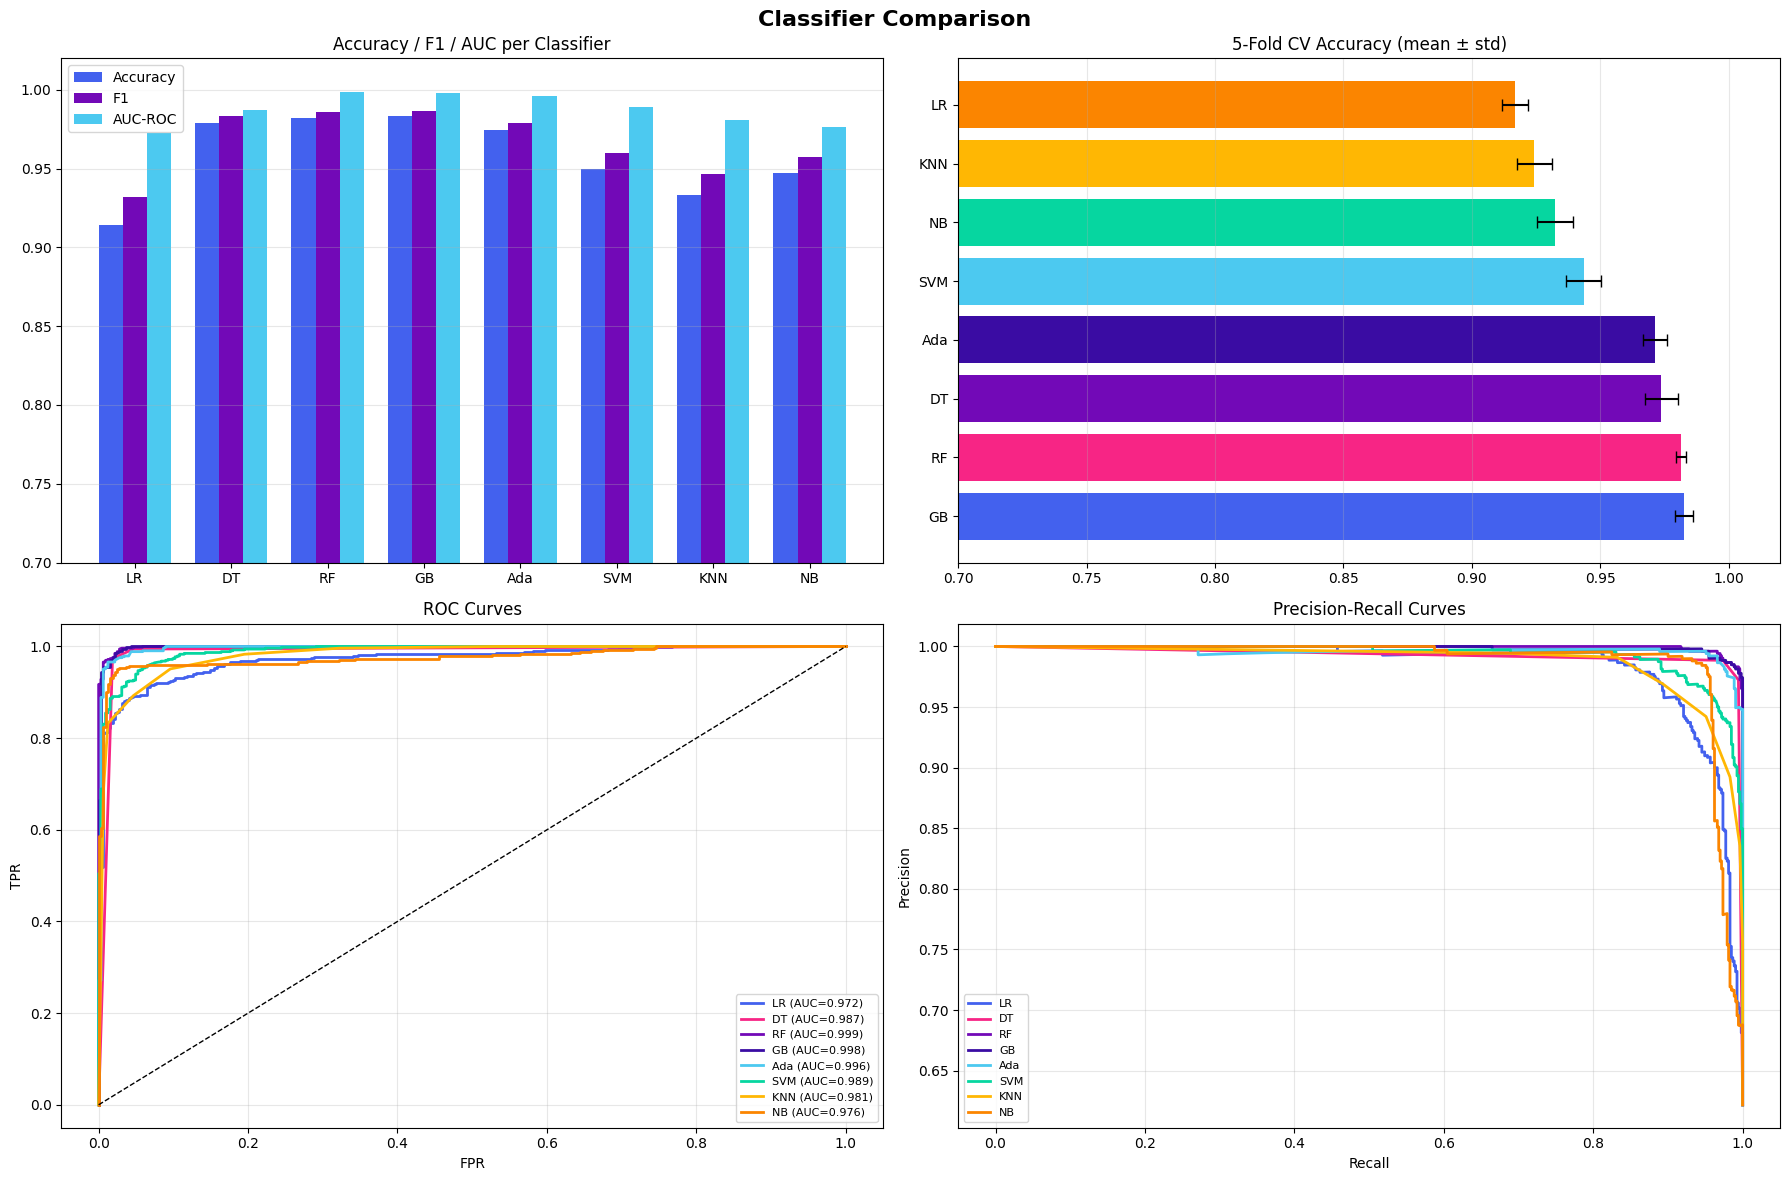

In [10]:
COLORS = ['#4361EE','#F72585','#7209B7','#3A0CA3','#4CC9F0','#06D6A0','#FFB703','#FB8500']
short  = ['LR','DT','RF','GB','Ada','SVM','KNN','NB']
names  = list(results.keys())

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Classifier Comparison', fontsize=16, fontweight='bold')

# Grouped bar: Accuracy / F1 / AUC
ax = axes[0,0]
x = np.arange(len(names)); w = 0.25
ax.bar(x-w,  [results[n]['accuracy'] for n in names], w, label='Accuracy',  color='#4361EE')
ax.bar(x,    [results[n]['f1']       for n in names], w, label='F1',        color='#7209B7')
ax.bar(x+w,  [results[n]['auc']      for n in names], w, label='AUC-ROC',   color='#4CC9F0')
ax.set_xticks(x); ax.set_xticklabels(short)
ax.set_ylim(0.7, 1.02); ax.legend(); ax.grid(axis='y', alpha=0.3)
ax.set_title('Accuracy / F1 / AUC per Classifier')

# CV accuracy horizontal bar
ax = axes[0,1]
cv_means = [results[n]['cv_mean'] for n in names]
cv_stds  = [results[n]['cv_std']  for n in names]
idx = np.argsort(cv_means)[::-1]
ax.barh([short[i] for i in idx], [cv_means[i] for i in idx],
        xerr=[cv_stds[i] for i in idx], color=COLORS, capsize=4)
ax.set_xlim(0.7, 1.02); ax.grid(axis='x', alpha=0.3)
ax.set_title('5-Fold CV Accuracy (mean ± std)')

# ROC curves
ax = axes[1,0]
for i, (name, color) in enumerate(zip(names, COLORS)):
    fpr, tpr, _ = roc_curve(y_test, results[name]['y_proba'])
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f"{short[i]} (AUC={results[name]['auc']:.3f})")
ax.plot([0,1],[0,1],'k--', lw=1)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC Curves'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

# Precision-Recall curves
ax = axes[1,1]
for i, (name, color) in enumerate(zip(names, COLORS)):
    prec, rec, _ = precision_recall_curve(y_test, results[name]['y_proba'])
    ax.plot(rec, prec, color=color, lw=2, label=short[i])
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 7.  Best Model Deep-Dive

In [11]:
best = results[best_name]
model = best['model']

print(f"Best Model: {best_name}")
print(f"Accuracy : {best['accuracy']:.4f}")
print(f"F1 Score : {best['f1']:.4f}")
print(f"AUC-ROC  : {best['auc']:.4f}")
print(f"CV Mean  : {best['cv_mean']:.4f} ± {best['cv_std']:.4f}")
print()
print("Classification Report:")
print(classification_report(y_test, best['y_pred'],
                             target_names=['Rejected','Approved']))


Best Model: Random Forest
Accuracy : 0.9824
F1 Score : 0.9859
AUC-ROC  : 0.9989
CV Mean  : 0.9815 ± 0.0020

Classification Report:
              precision    recall  f1-score   support

    Rejected       0.98      0.97      0.98       323
    Approved       0.98      0.99      0.99       531

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854



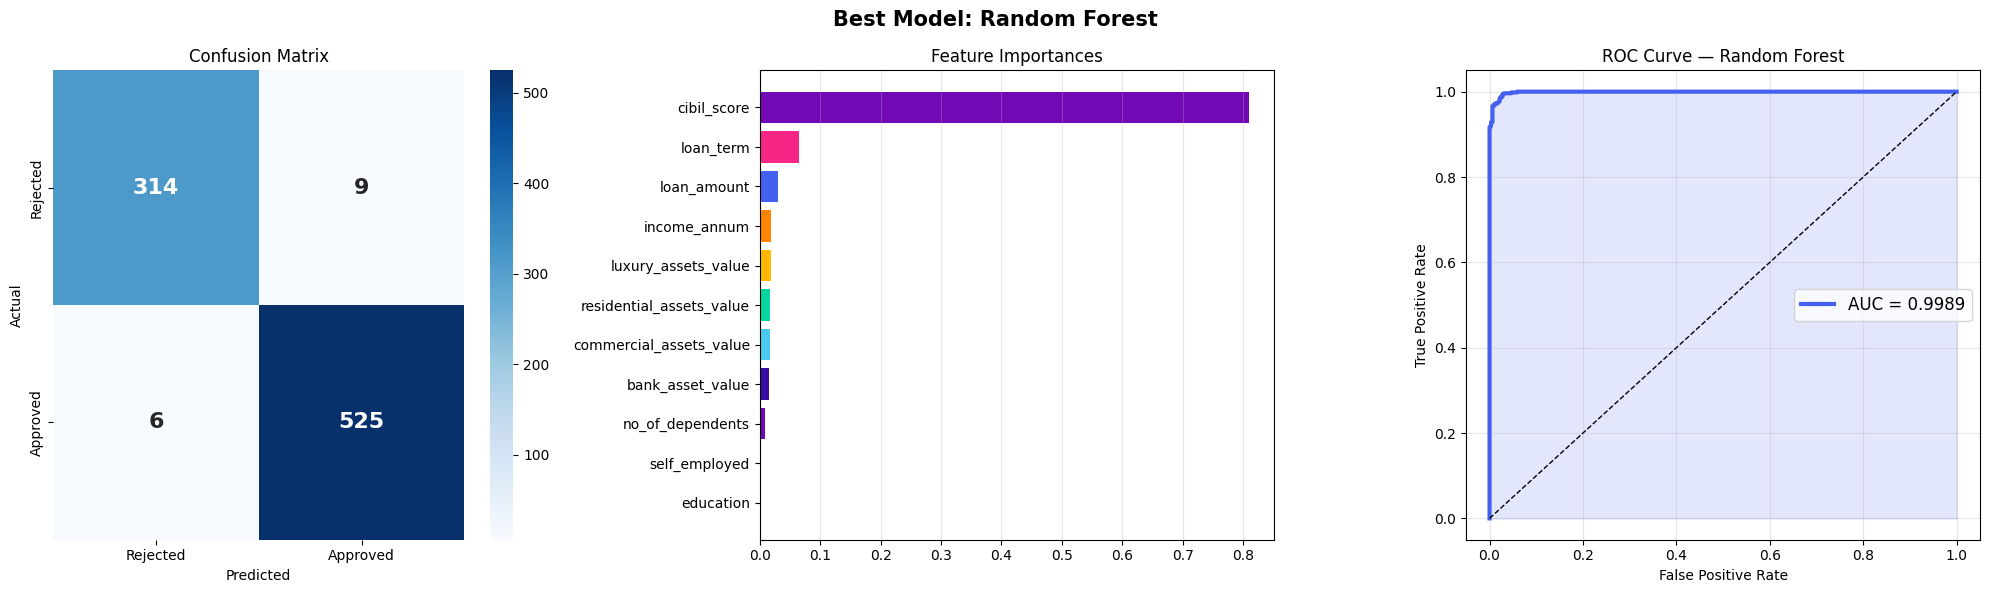

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle(f'Best Model: {best_name}', fontsize=15, fontweight='bold')

# Confusion matrix
cm = confusion_matrix(y_test, best['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', ax=axes[0], cmap='Blues',
            xticklabels=['Rejected','Approved'],
            yticklabels=['Rejected','Approved'],
            annot_kws={'size':16, 'weight':'bold'})
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')
axes[0].set_title('Confusion Matrix')

# Feature importances
if hasattr(model, 'feature_importances_'):
    fi = model.feature_importances_
elif hasattr(model, 'coef_'):
    fi = np.abs(model.coef_[0])
else:
    fi = np.ones(len(feature_names))

order = np.argsort(fi)
axes[1].barh([feature_names[i] for i in order], fi[order],
             color=[COLORS[i % len(COLORS)] for i in range(len(order))])
axes[1].set_title('Feature Importances')
axes[1].grid(axis='x', alpha=0.3)

# ROC curve of best model
fpr, tpr, _ = roc_curve(y_test, best['y_proba'])
axes[2].plot(fpr, tpr, color='#4361EE', lw=3,
             label=f"AUC = {best['auc']:.4f}")
axes[2].fill_between(fpr, tpr, alpha=0.15, color='#4361EE')
axes[2].plot([0,1],[0,1],'k--', lw=1)
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].set_title(f'ROC Curve — {best_name}')
axes[2].legend(fontsize=12); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 8.  Final Summary Table

In [13]:
summary = pd.DataFrame([{
    'Model'    : name,
    'Accuracy' : f"{r['accuracy']:.4f}",
    'F1 Score' : f"{r['f1']:.4f}",
    'AUC-ROC'  : f"{r['auc']:.4f}",
    'CV Mean'  : f"{r['cv_mean']:.4f}",
    'CV Std'   : f"{r['cv_std']:.4f}",
} for name, r in results.items()])

summary = summary.sort_values('AUC-ROC', ascending=False).reset_index(drop=True)
summary.index += 1
summary.style.set_caption("Model Performance Summary (sorted by AUC-ROC)")


,Model,Accuracy,F1 Score,AUC-ROC,CV Mean,CV Std
1,Random Forest,0.9824,0.9859,0.9989,0.9815,0.0020
2,Gradient Boosting,0.9836,0.9869,0.9981,0.9827,0.0035
3,AdaBoost,0.9742,0.9792,0.9959,0.9714,0.0046
4,SVM,0.9496,0.9596,0.9893,0.9435,0.0069
5,Decision Tree,0.9789,0.9832,0.9873,0.9738,0.0064
6,K-Nearest Neighbors,0.9333,0.9466,0.9809,0.9243,0.0068
7,Naive Bayes,0.9473,0.9577,0.9765,0.9323,0.0071
8,Logistic Regression,0.9145,0.9320,0.9725,0.9168,0.0052
